Congiguration file

In [1]:

import json



List of files expected by this script 

In [2]:

#pattern_0
patterns_0_file='patterns_0.npy'

#scatter plot
scatter_unlearned_file=f"a1a2a3_NotLed.npz"  
scatter_file=f"a1a2a3_D2.npz"

loss_file=f"loss_D2.npz"
activities_file=f"activities_D2.npz"
hidden_file=f"hidden_conc_D2.npz"
K_fin_matrix=f"K_matrix_D2.json"
CN_state_file=f"CN_state_D2.npz"
list_K_file=f"list_K_matrix_D2.npy"


Visualize the patterns

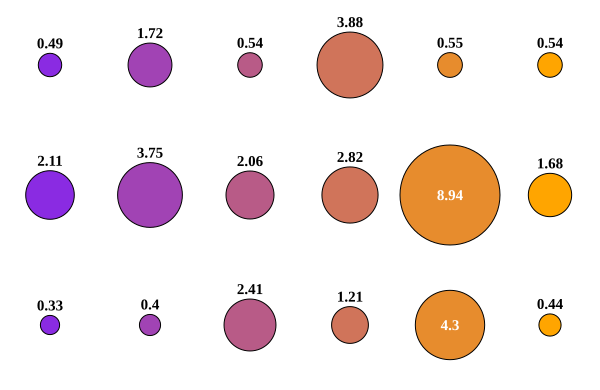

In [3]:

import math
import numpy as np
import IPython.display as disp

# Load the data from the .npy file
patterns_0 = np.load(patterns_0_file)

# The data array
data = np.round(patterns_0, 2)

rows = len(data)
cols = len(data[0])
cell_width = 100  # width of each cell in pixels
cell_height = 130 # height of each cell in pixels

# Maximum circle radius for the maximum value in the data.
max_radius = 50
max_value = max(max(row) for row in data)
# Compute a scale factor so that the largest value produces a circle with area = π*max_radius^2.
scale = (math.pi * max_radius**2) / max_value

def radius_for_value(val):
    # Compute circle radius from its area: area = scale * value, r = sqrt(area/π)
    area = scale * val
    return math.sqrt(area / math.pi)

def interpolate_color(col, total_cols, start_color, end_color):
    """
    Linearly interpolate between start_color and end_color.
    Colors are given as (R, G, B) tuples (0-255).
    Returns the interpolated color as a hex string.
    """
    ratio = col / (total_cols - 1) if total_cols > 1 else 0
    r = int(start_color[0] + ratio * (end_color[0] - start_color[0]))
    g = int(start_color[1] + ratio * (end_color[1] - start_color[1]))
    b = int(start_color[2] + ratio * (end_color[2] - start_color[2]))
    return f"#{r:02x}{g:02x}{b:02x}"

# Define start and end colors for columns (green to orange).
violet = (138, 43, 226)     # green in RGB
orange = (255, 165, 0)  # orange in RGB

# Compute overall SVG canvas size.
svg_width = cols * cell_width
svg_height = rows * cell_height

# Start the SVG output.
svg_parts = [
    f'<svg xmlns="http://www.w3.org/2000/svg" width="{svg_width}" height="{svg_height}">'
]

# Loop over the data and generate circles and text.
for r in range(rows):
    for c in range(cols):
        value = data[r][c]
        # Determine circle center in the cell.
        cx = c * cell_width + cell_width / 2
        cy = r * cell_height + cell_height / 2
        r_circle = radius_for_value(value)
        # Compute color for the column by interpolating from green to orange.
        fill_color = interpolate_color(c, cols, violet, orange)

        # Create a circle element.
        circle_svg = f'<circle cx="{cx}" cy="{cy}" r="{r_circle:.2f}" fill="{fill_color}" stroke="black" />'
        svg_parts.append(circle_svg)

        # Determine where to place the text:

        if value < 4:
            # Place the text a little above the circle (subtract the radius plus extra padding)
            text_y = cy - r_circle - 5
            text_color = "black"
            text_anchor = "middle"
            dominant_baseline = "baseline"
        else:
            text_y = cy
            if c==5: text_color = "black"
            else: text_color = "white"
            text_anchor = "middle"
            dominant_baseline = "central"

        text_svg = f'<text x="{cx}" y="{text_y}" font-size="15" text-anchor="{text_anchor}" dominant-baseline="{dominant_baseline}" fill="{text_color}" font-weight="bold" >{value}</text>'
        svg_parts.append(text_svg)

svg_parts.append('</svg>')
svg_output = "\n".join(svg_parts)

# Save the SVG to a file (optional)
with open("visualization.svg", "w") as f:
    f.write(svg_output)

# Display the SVG preview (works in Jupyter Notebook)
disp.display(disp.SVG(svg_output))

Scatter plot

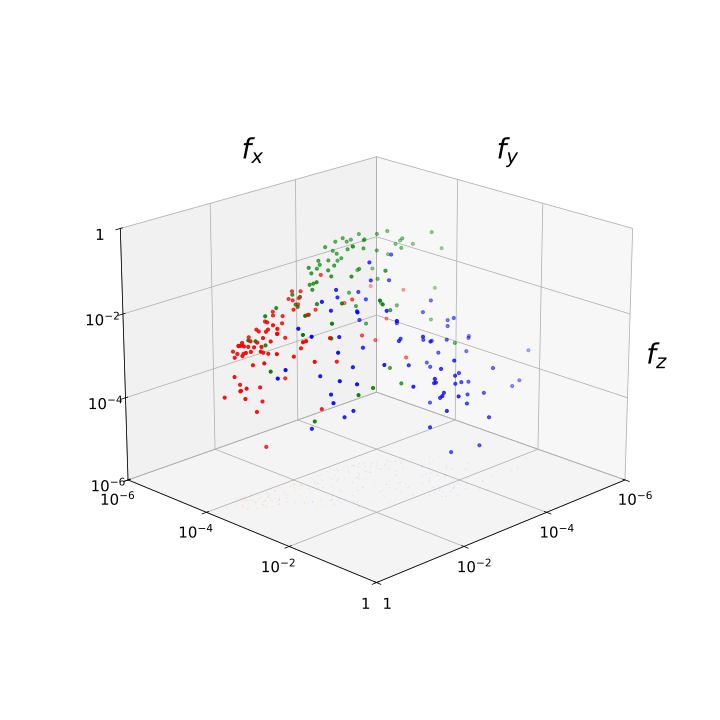

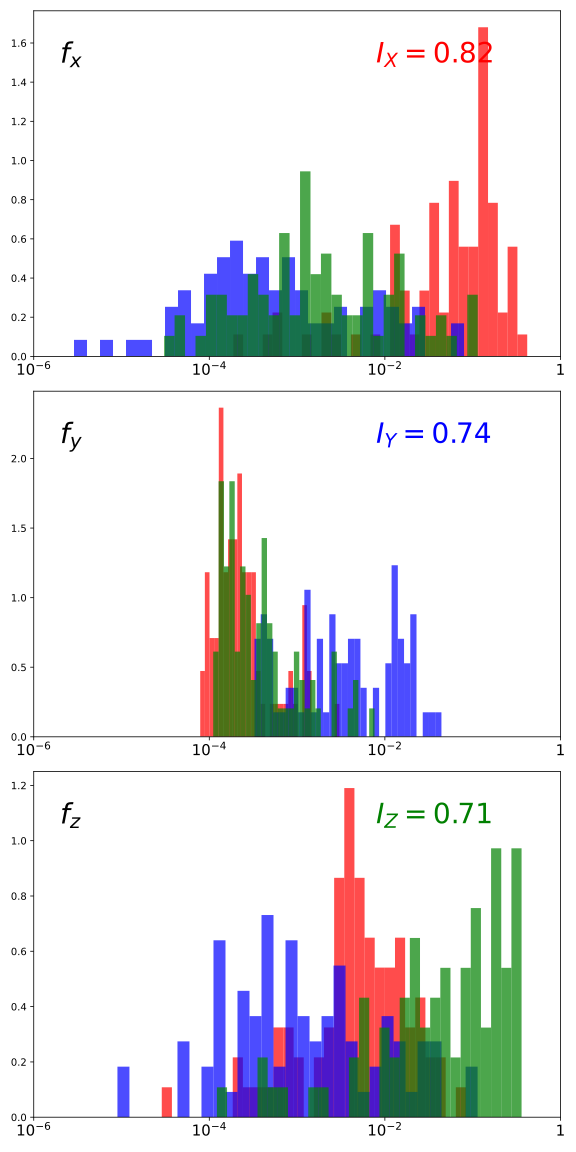

In [4]:

import numpy as np
data = np.load(scatter_file)
a1, a2, a3 = np.copy(data['arr1']), np.copy(data['arr2']), np.copy(data['arr3'])
data = np.load(scatter_unlearned_file)
a1_0, a2_0, a3_0 = np.copy(data['arr1']), np.copy(data['arr2']), np.copy(data['arr3'])


import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # For 3D plotting
import IPython.display as disp

def compute_entropy(x, dx=0.02):
    """
    Compute the discrete Shannon entropy for a one-dimensional array x.
    The distribution is estimated using a histogram with bin width dx.
    
    Parameters:
      x  : 1D numpy array of data.
      dx : The width of each bin (default 0.02).
    
    Returns:
      The computed Shannon entropy.
    """
    # Define bin edges from the minimum to maximum value of x, using dx as step.
    edges = np.arange(np.min(x), np.max(x) + dx, dx)
    counts, _ = np.histogram(x, bins=edges, density=False)
    total = np.sum(counts)
    if total == 0:
        return 0
    p = counts / total
    # Filter out zero probabilities to avoid log(0)
    p = p[p > 0]
    return -np.sum(p * np.log(p))




def generate_svg_plots(a_list, colors, lower_bound=-6, scatter_filename="scatter.svg", hist_filename="histograms.svg"):
    """
    Generates two distinct SVG plots:
      1. A 3D scatter plot (with shadows projected onto the xy-plane).
      2. Histograms of the f_x, f_y, and f_z components (stacked vertically).
    
    In addition, calculates the entropy H_x of the x distribution for each dataset,
    for the combined distribution (all datasets concatenated),
    and for the combination of datasets 1 and 2.
    Then computes a mutual entropy as:
    
         I_x = H_x(combined) - (1/3*H_x(0) + 2/3*H_x(1,2))
    
    Both SVG outputs preserve editable text.
    
    Parameters:
      a_list       : list of numpy arrays, each with shape (n, 3) containing positive values.
      colors       : list of three color strings, one for each dataset.
      lower_bound  : fixed z-value for the xy-plane shadow and lower limit of the axes.
      scatter_filename : filename for the scatter plot SVG.
      hist_filename    : filename for the histograms SVG.
    """
    # Combine the three datasets into a list.
    
    # Scaling factor: convert natural logs to base-10 logs.
    Dec = 1 / np.log(10)
    I_max=1/3*np.log(3)+2/3*np.log(3/2)
    # Compute transformed data for each dataset.
    all_x, all_y, all_z = [], [], []
    for a in a_list:
        x = Dec * np.log(a[:, 0])
        y = Dec * np.log(a[:, 1])
        z = Dec * np.log(a[:, 2])
        all_x.append(x)
        all_y.append(y)
        all_z.append(z)

        # Compute entropies for the x distributions.
    # H0: for first dataset; H1: for second; H2: for third.
    H0 = compute_entropy(all_x[0])
    H1 = compute_entropy(all_y[1])
    H2 = compute_entropy(all_z[2])
    combined_12 = np.concatenate([all_x[1], all_x[2]])
    combined_02 = np.concatenate([all_y[0], all_y[2]])
    combined_01 = np.concatenate([all_z[0], all_z[1]])
        # Combined: concatenate all x values.
    combined_x = np.concatenate(all_x)
    combined_y = np.concatenate(all_y)
    combined_z = np.concatenate(all_z)
    H_12 = compute_entropy(combined_12)
    H_02 = compute_entropy(combined_02)
    H_01 = compute_entropy(combined_01)


    mutual_information_x = compute_entropy(combined_x) - (1/3 * H0 + 2/3 * H_12)
    mutual_information_y = compute_entropy(combined_y) - (1/3 * H1 + 2/3 * H_02)
    mutual_information_z = compute_entropy(combined_z) - (1/3 * H2 + 2/3 * H_01)
    mutual_information_x=mutual_information_x/I_max
    mutual_information_y=mutual_information_y/I_max
    mutual_information_z=mutual_information_z/I_max
    
    # Define tick positions from 0 to lower_bound in steps of -2.
    ticks = np.arange(0, lower_bound - 0.1, -2)  # subtract small value to ensure inclusion
    # Create tick labels: 0 is displayed as "1", other ticks as 10^{n}.
    labels = ["1" if tick == 0 else r'$10^{' + str(int(tick)) + '}$' for tick in ticks]
    font_size=28
    label_font=15

    # ======================================================
    # 1. Create the 3D Scatter Plot with Shadows and Export SVG
    # ======================================================
    fig_scatter = plt.figure(figsize=(10, 10))
    ax_scatter = fig_scatter.add_subplot(111, projection='3d')
   
    point_size = 10      # marker size for scatter points
    shadow_alpha = 0.05  # transparency for shadow points
    shadow_size = 1      # marker size for shadows
    
    # Plot each dataset in its color.
    for i, color in enumerate(colors):
        x = all_x[i]
        y = all_y[i]
        z = all_z[i]
        ax_scatter.scatter(x, y, z, color=color, s=point_size)
        # Plot shadow by re-plotting with z fixed at lower_bound.
        ax_scatter.scatter(x, y, zs=lower_bound, zdir='z', color=color, alpha=shadow_alpha, s=shadow_size)
    
    # Remove default axis labels; add custom axis names via text.
    ax_scatter.set_xlabel('')
    ax_scatter.set_ylabel('')
    ax_scatter.set_zlabel('')
    ax_scatter.text2D(0.27, 0.87, r'$f_x$', fontsize=font_size, transform=ax_scatter.transAxes)
    ax_scatter.text2D(0.73, 0.87, r'$f_y$', fontsize=font_size, transform=ax_scatter.transAxes)
    ax_scatter.text2D(1.0, 0.5, r'$f_z$', fontsize=font_size, transform=ax_scatter.transAxes)
    
    # Set limits for each axis.
    ax_scatter.set_xlim(lower_bound, 0)
    ax_scatter.set_ylim(lower_bound, 0)
    ax_scatter.set_zlim(lower_bound, 0)
    
    # Apply same ticks/labels on all three axes.
    ax_scatter.set_xticks(ticks)
    ax_scatter.set_xticklabels(labels, fontsize=label_font)
    ax_scatter.set_yticks(ticks)
    ax_scatter.set_yticklabels(labels,fontsize=label_font)
    ax_scatter.set_zticks(ticks)
    ax_scatter.set_zticklabels(labels,fontsize=label_font)
    
    ax_scatter.view_init(elev=20, azim=45)
    #ax_scatter.set_title("3D Scatter Plot with Shadows", fontsize=16)
    #fig_scatter.tight_layout()
    # Export scatter plot to SVG.
    fig_scatter.savefig(scatter_filename, facecolor='none', transparent=True, format="svg")
    plt.close(fig_scatter)
    
    # ======================================================
    # 2. Create the Histograms Plot and Export SVG
    # ======================================================
    # Create a figure with three vertically stacked subplots.
    fig_hist = plt.figure(figsize=(8, 16))
    ax_hist_x = fig_hist.add_subplot(311)
    ax_hist_y = fig_hist.add_subplot(312)
    ax_hist_z = fig_hist.add_subplot(313)

    bins = 30  # number of bins for the histograms.
    
    # Plot histogram for f_x.
    for i, color in enumerate(colors):
        ax_hist_x.hist(all_x[i], bins=bins, color=color,density=True, alpha=0.7)
    # Plot histogram for f_y.
    for i, color in enumerate(colors):
        ax_hist_y.hist(all_y[i], bins=bins, color=color,density=True, alpha=0.7)
    # Plot histogram for f_z.
    for i, color in enumerate(colors):
        ax_hist_z.hist(all_z[i], bins=bins, color=color,density=True, alpha=0.7)
    
    # Set common x-axis limits and ticks for each histogram subplot.
    for ax_hist in [ax_hist_x, ax_hist_y, ax_hist_z]:
        ax_hist.set_xlim(lower_bound, 0)
        ax_hist.set_xticks(ticks)
        ax_hist.set_xticklabels(labels, fontsize=label_font)
        #ax_hist.set_yticklabels(ax_hist.get_yticks(), fontsize=label_font)
    
    ax_hist_x.text(0.05, 0.85, r'$f_x$', fontsize=font_size, transform=ax_hist_x.transAxes)
    ax_hist_y.text(0.05, 0.85, r'$f_y$', fontsize=font_size, transform=ax_hist_y.transAxes)
    ax_hist_z.text(0.05, 0.85, r'$f_z$', fontsize=font_size, transform=ax_hist_z.transAxes)

    ax_hist_x.text(0.65, 0.85, f'$I_X = {mutual_information_x:.2f}$', fontsize=font_size, color='red', transform=ax_hist_x.transAxes)
    ax_hist_y.text(0.65, 0.85, f'$I_Y = {mutual_information_y:.2f}$', fontsize=font_size, color='blue', transform=ax_hist_y.transAxes)
    ax_hist_z.text(0.65, 0.85, f'$I_Z = {mutual_information_z:.2f}$', fontsize=font_size, color='green', transform=ax_hist_z.transAxes)

    #ax_hist_x.set_title(r'Histogram of $f_x$', fontsize=14)
    #ax_hist_y.set_title(r'Histogram of $f_y$', fontsize=14)
    #ax_hist_z.set_title(r'Histogram of $f_z$', fontsize=14)
    
    fig_hist.tight_layout()
    # Export histogram plot to SVG.
    fig_hist.savefig(hist_filename, format="svg")
    plt.close(fig_hist)
    
    # Optionally, display the SVG files in a Jupyter Notebook.
    disp.display(disp.SVG(filename=scatter_filename))
    disp.display(disp.SVG(filename=hist_filename))

# ========================
# Example Usage:
# Assume a1, a2, a3 are numpy arrays with shape (n, 3) containing positive values.
# For example:


colors = ['red', 'blue', 'green']

# Generate the SVG plots.
generate_svg_plots([a1, a2, a3], colors, lower_bound=-6)
#generate_svg_plots([a1_0, a2_0, a3_0], colors, lower_bound=-6)



Plot of the loss function and running average of the output activities 

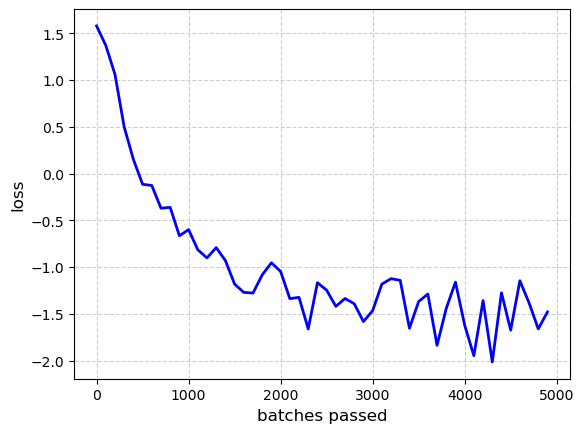

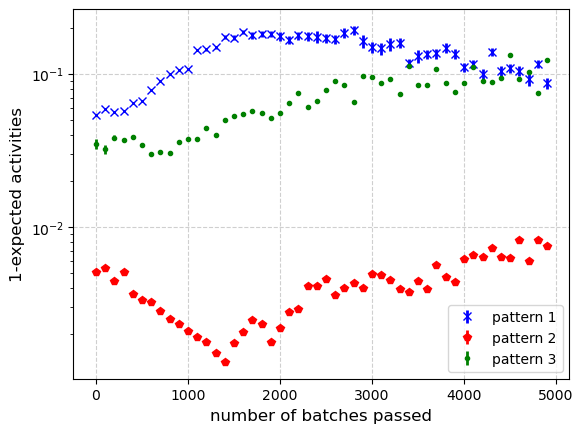

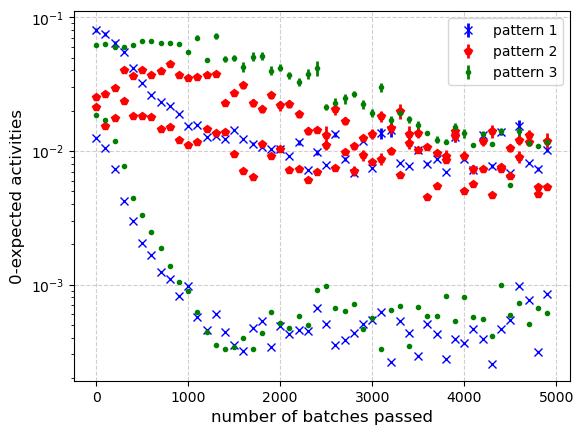

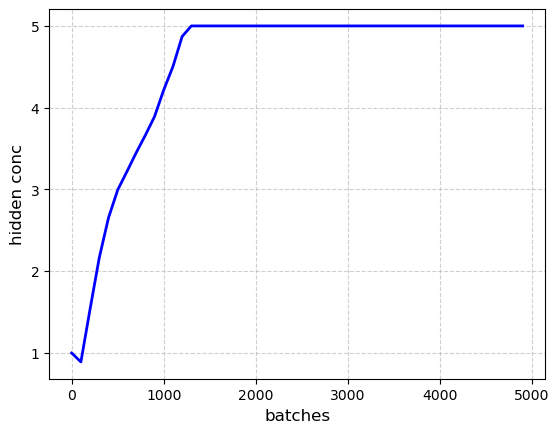

In [5]:

# load loss 
data = np.load(loss_file)
list_batches, list_loss = np.copy(data['arr1']), np.copy(data['arr2'])

import matplotlib.pyplot as plt
plt.plot(list_batches, list_loss, color='blue', linewidth=2)
plt.xlabel('batches passed', fontsize=12)  # Label for the X-axis
plt.ylabel('loss', fontsize=12)  # Label for the Y-axis
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


# load activities
filename = f"activities_D2.npz"
data=np.load(activities_file)
list_batches, list_a_patt1, list_a_var_patt1, \
    list_a_patt2, list_a_var_patt2, \
    list_a_patt3, list_a_var_patt3 = np.copy(data['arr1']), \
    np.copy(data['arr2']), np.copy(data['arr3']), \
    np.copy(data['arr4']), np.copy(data['arr5']), \
    np.copy(data['arr6']), np.copy(data['arr7'])

plt.errorbar(list_batches, list_a_patt1[:,0], yerr=list_a_var_patt1[:,0], fmt='x', label='pattern 1', color='blue', linewidth=2)
plt.errorbar(list_batches, list_a_patt2[:,1], yerr=list_a_var_patt1[:,1], fmt='p', label='pattern 2', color='red', linewidth=2)
plt.errorbar(list_batches, list_a_patt3[:,2], yerr=list_a_var_patt1[:,2], fmt='.', label='pattern 3', color='green', linewidth=2)

plt.xlabel('number of batches passed', fontsize=12)  # Label for the X-axis
plt.ylabel('1-expected activities', fontsize=12)  # Label for the Y-axis
plt.legend(fontsize=10)  # Display the legend
plt.grid(True, linestyle='--', alpha=0.6)
plt.yscale('log')
plt.show()


plt.errorbar(list_batches, list_a_patt1[:,1], yerr=list_a_var_patt1[:,1], fmt='x', label='pattern 1', color='blue', linewidth=2)
plt.errorbar(list_batches, list_a_patt1[:,2], yerr=list_a_var_patt1[:,2], fmt='x', color='blue', linewidth=2)
plt.errorbar(list_batches, list_a_patt2[:,0], yerr=list_a_var_patt2[:,0], fmt='p', label='pattern 2', color='red', linewidth=2)
plt.errorbar(list_batches, list_a_patt2[:,2], yerr=list_a_var_patt2[:,2], fmt='p', color='red', linewidth=2)
plt.errorbar(list_batches, list_a_patt3[:,0], yerr=list_a_var_patt3[:,0], fmt='.', label='pattern 3', color='green', linewidth=2)
plt.errorbar(list_batches, list_a_patt3[:,1], yerr=list_a_var_patt3[:,1], fmt='.', color='green', linewidth=2)
#
plt.xlabel('number of batches passed', fontsize=12)  # Label for the X-axis
plt.ylabel('0-expected activities', fontsize=12)  # Label for the Y-axis
plt.legend(fontsize=10)  # Display the legend
plt.grid(True, linestyle='--', alpha=0.6)
plt.yscale('log')
plt.show()


#load hidden concentration
data = np.load(hidden_file)
list_batches, list_conc_hidden = np.copy(data['arr1']), np.copy(data['arr2'])

plt.plot(list_batches, list_conc_hidden, color='blue', linewidth=2)
plt.xlabel('batches', fontsize=12)  # Label for the X-axis
plt.ylabel('hidden conc', fontsize=12)  # Label for the Y-axis
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()



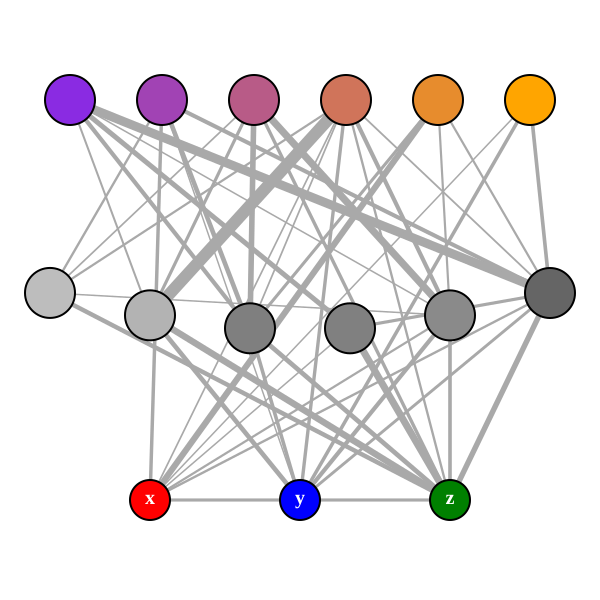

In [27]:


with open(K_fin_matrix, 'r') as file:
            k_data = json.load(file)
            K = np.array(k_data['K'])

import numpy as np
import random
K_cut_off = 1
adj_matrix = K.copy()  # Make a copy so as not to modify the original matrix
adj_matrix[adj_matrix < K_cut_off] = 0

# -------- Parameters for layout ----------
# SVG canvas dimensions
width, height = 600, 600

# Define y positions for the three layers (top-to-bottom).
# Note: In SVG, y increases downward.
y_positions = [100, 300, 500]  # first layer at top, third layer at bottom

# Define x positions for each layer.
def get_x_positions(n, margin=50):
    # Evenly space n vertices horizontally between margin and width-margin.
    return np.linspace(margin, width - margin, n)

# Get positions for each layer.
x_positions_layer1 = get_x_positions(6, margin=70)
x_positions_layer2 = get_x_positions(6)
x_positions_layer3 = get_x_positions(3, margin=150)

# Build the list of vertex positions.
# Order: first layer (top), then second, then third.
positions = []
# First layer (6 vertices) at y_positions[0]
for x in x_positions_layer1:
    positions.append((x, y_positions[0]))
# Second layer (6 vertices) at y_positions[1] with slight variation.
for x in x_positions_layer2:
    positions.append((x, y_positions[1] - 20 + 50 * np.sin(3.14 * (x / 600))))
# Third layer (3 vertices) at y_positions[2]
for x in x_positions_layer3:
    positions.append((x, y_positions[2]))

# -------- Colors for vertices ----------
def hex_color(r, g, b):
    return f"#{r:02x}{g:02x}{b:02x}"

# Gradient from violet to orange for layer 1.
# Violet: (138, 43, 226)  --> hex "#8a2be2"
# Orange: (255, 165, 0)   --> hex "#ffa500"
layer1_colors = []
n1 = 6
for i in range(n1):
    ratio = i / (n1 - 1) if n1 > 1 else 0
    r = int(138 + ratio * (255 - 138))
    g = int(43 + ratio * (165 - 43))
    b = int(226 + ratio * (0 - 226))
    layer1_colors.append(hex_color(r, g, b))

# For layer 2, random shades of gray (use same value for R, G, B between 100 and 200)
layer2_colors = []
n2 = 6
for _ in range(n2):
    v = random.randint(100, 200)
    layer2_colors.append(hex_color(v, v, v))

# For layer 3, fixed colors: red, blue, green.
layer3_colors = ['red', 'blue', 'green']

# Combine all vertex colors in order.
vertex_colors = layer1_colors + layer2_colors + layer3_colors


# Define a scaling factor for edge thickness.
edge_scale = 1
norm = 12 / np.log(np.max(adj_matrix) + 1)

# -------- SVG Generation ----------
svg_lines = []
svg_lines.append(f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}">')

# Draw edges.
# Draw an edge (line) for each pair (i,j) with i < j if weight > 0.
for i in range(15):
    for j in range(i+1, 15):
        weight = norm * np.log(adj_matrix[i, j] + 1)
        if weight > 0:
            # Get positions for vertex i and vertex j.
            x1, y1 = positions[i]
            x2, y2 = positions[j]
            # Stroke width proportional to weight.
            stroke_width = weight * edge_scale
            svg_lines.append(f'<line x1="{x1}" y1="{y1}" x2="{x2}" y2="{y2}" stroke="darkgrey" stroke-width="{stroke_width:.2f}" />')

# Draw vertices as circles with different sizes.
# First and second layers: radius 25; third layer: radius 15.
for i, (x, y) in enumerate(positions):
    color = vertex_colors[i]
    if i < 12:
        radius = 25
        svg_lines.append(f'<circle cx="{x}" cy="{y}" r="{radius}" fill="{color}" stroke="black" stroke-width="2" />')
    else:
        radius = 20
        svg_lines.append(f'<circle cx="{x}" cy="{y}" r="{radius}" fill="{color}" stroke="black" stroke-width="2" />')
        # For the last three vertices, add labels 'x', 'y', 'z' in white bold.
        label = ['x', 'y', 'z'][i - 12]
        svg_lines.append(f'<text x="{x}" y="{y+4}" font-size="20" text-anchor="middle" fill="white" font-weight="bold">{label}</text>')

svg_lines.append('</svg>')

svg_output = "\n".join(svg_lines)

# Write the SVG output to a file.
with open("neural_network_top_to_bottom.svg", "w") as f:
    f.write(svg_output)

# Optionally, display the SVG in a Jupyter Notebook.
from IPython.display import SVG, display
display(SVG(svg_output))

Combine the three subplots

In [35]:
import xml.etree.ElementTree as ET

def extract_svg_children(svg_str):
    """
    Parse the SVG string and return the string representation of all
    children of the root <svg> element.
    """
    # Parse the SVG.
    root = ET.fromstring(svg_str)
    # Collect the string representations of all children.
    children_str = "\n".join(ET.tostring(child, encoding="unicode") for child in list(root))
    return children_str

# Example usage:
with open("scatter.svg", "r") as f:
    scatter_svg = f.read()
scatter_content = extract_svg_children(scatter_svg)

from IPython.display import SVG, display

# Read the constituent SVG files.
with open("visualization.svg", "r") as f:
    patterns_svg = f.read()
with open("base.svg", "r") as f:
    base_svg = f.read()
with open("scatter.svg", "r") as f:
    scatter_svg = f.read()
with open("neural_network_top_to_bottom.svg", "r") as f:
    network_svg = f.read()
with open("histograms.svg", "r") as f:
    hist_svg = f.read()

# Extract inner content (children) using the XML parser.
patterns_content = extract_svg_children(patterns_svg)
base_content = extract_svg_children(base_svg)
scatter_content = extract_svg_children(scatter_svg)
network_content = extract_svg_children(network_svg)
hist_content = extract_svg_children(hist_svg)

# Define composite dimensions.
composite_width = 1250
composite_height = 1650
font_size_caption = 28

# Create a composite SVG.
# (Note: If any of your constituent SVGs have <defs> or <metadata>,
# you might want to extract those once and insert them at the top of your composite.)
composite_svg = f'''<svg xmlns="http://www.w3.org/2000/svg" 
       xmlns:xlink="http://www.w3.org/1999/xlink"
       width="{composite_width}" height="{composite_height}" viewBox="0 0 {composite_width} {composite_height}">
  <!-- Panel (a): Input cocktails -->
  <g id="panel_a" transform="translate(70,50)">
    <rect x="0" y="0" width="600" height="450" fill="none" stroke="none"/>
    {patterns_content}
    <text x="-55" y="-20" font-size="{font_size_caption}" font-weight="bold" text-anchor="start" fill="black" font-family="Arial">
      a) Input cocktails
    </text>
  </g>

  <!-- Panel (b): Desired outputs -->
  <g id="panel_b" transform="translate(10,100)">
    <rect x="0" y="0" width="250" height="250" fill="none" stroke="none"/>
    {base_content}
    <text x="780" y="-70" font-size="{font_size_caption}" font-weight="bold" text-anchor="start" fill="black" font-family="Arial">
      b) Desired outputs
    </text>
  </g>

  <!-- Panel (c): Output fugacities -->
  <g id="panel_c" transform="translate(-50,400)">
    <rect x="0" y="0" width="600" height="600" fill="none" stroke="none"/>
    {scatter_content}
    <text x="60" y="80" font-size="{font_size_caption}" font-weight="bold" text-anchor="start" fill="black" font-family="Arial">
      c) Output fugacities
    </text>
  </g>
  
  <!-- Panel (e): Evolved dimerization network -->
  <g id="panel_e" transform="translate(0,1050)">
    <rect x="0" y="0" width="600" height="600" fill="none" stroke="none"/>
    {network_content}
    <text x="10" y="30" font-size="{font_size_caption}" font-weight="bold" text-anchor="start" fill="black" font-family="Arial">
      e) Evolved dimerization network
    </text>
  </g>
  
  <!-- Panel (d): Fugacity distributions -->
  <g id="panel_d" transform="translate(650,500)">
    <rect x="0" y="0" width="600" height="1200" fill="none" stroke="none"/>
    {hist_content}
    <text x="10" y="-20" font-size="{font_size_caption}" font-weight="bold" text-anchor="start" fill="black" font-family="Arial">
      d) Fugacity distributions
    </text>
  </g>
</svg>'''

# Write the composite SVG to a file.
with open("composite.svg", "w") as f:
    f.write(composite_svg)

# Optionally, display the composite SVG in a Jupyter Notebook.
#display(SVG(composite_svg))


Colormap for the learned matrix K

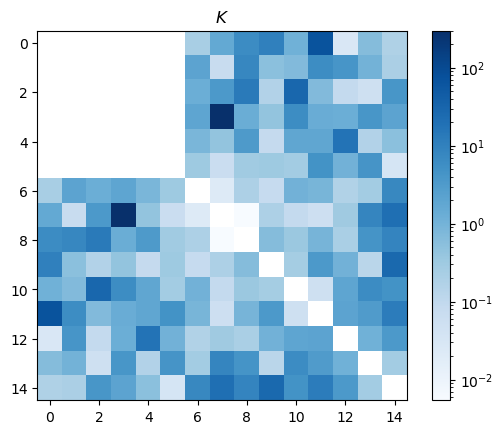

In [31]:

from matplotlib.colors import LogNorm

# Create a matrix
matrix = np.random.rand(10, 10)

# Plot with a colormap (e.g., 'plasma')
plt.imshow(K, cmap='Blues', norm=LogNorm())
plt.colorbar()  # Optional: Adds a colorbar to the side
plt.title(r'$K$')
plt.show()

# -----------




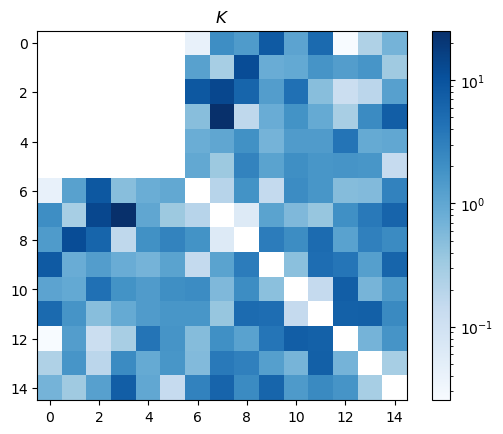

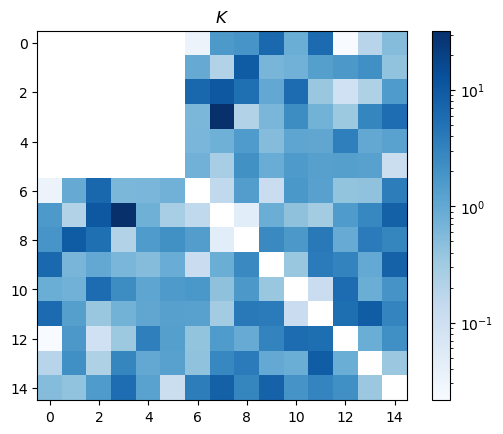

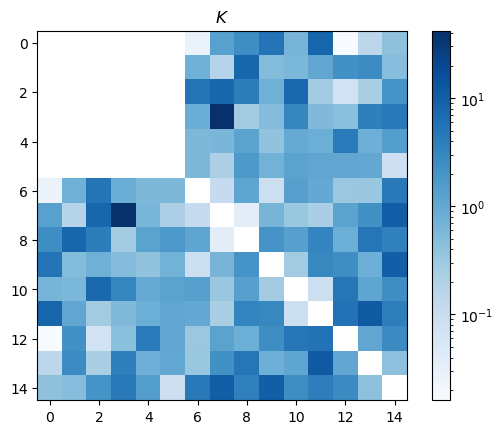

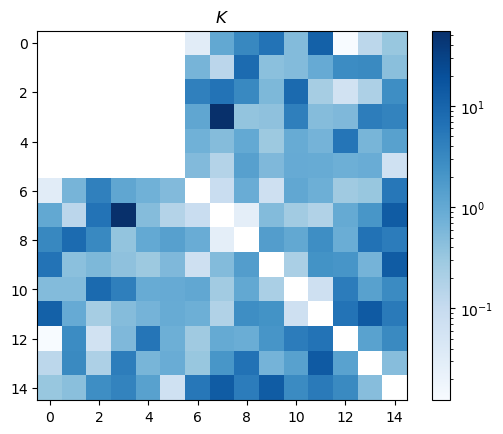

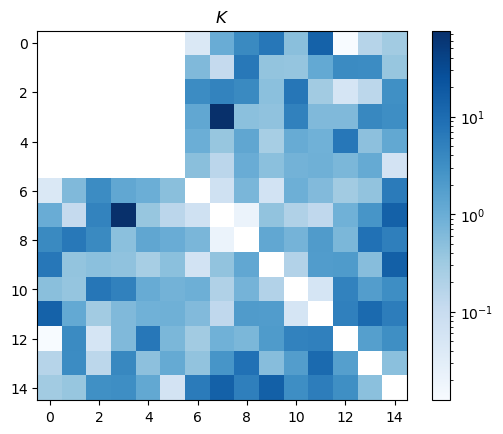

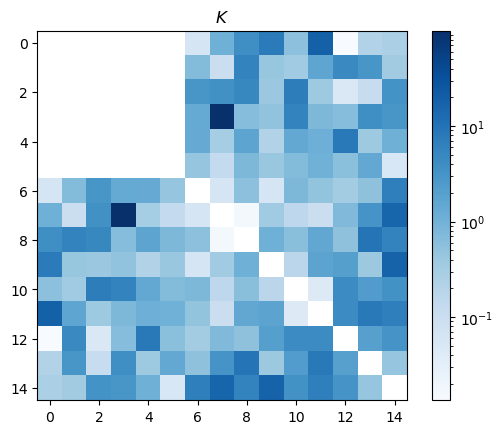

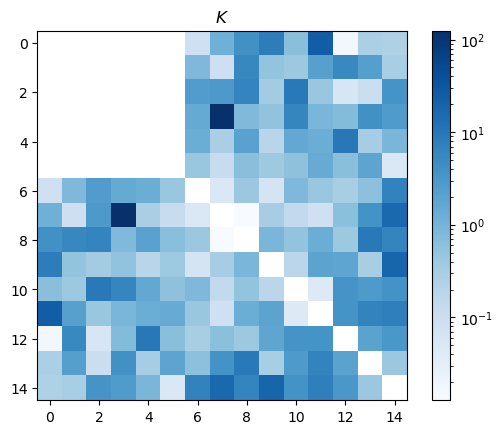

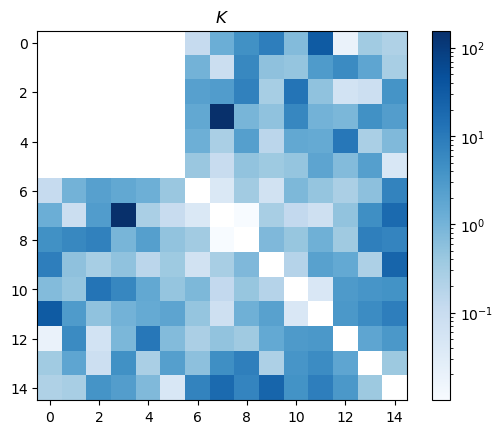

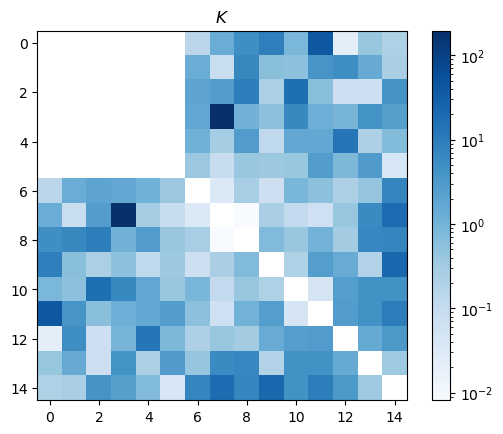

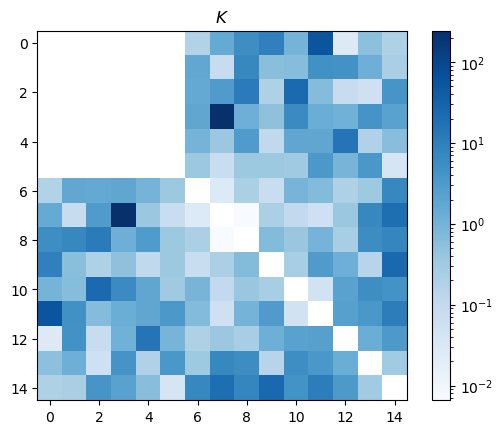

In [33]:

list_Ks = np.load(list_K_file)

for i in range(len(list_Ks)):
    plt.imshow(list_Ks[i], cmap='Blues', norm=LogNorm())
    plt.colorbar()  # Optional: Adds a colorbar to the side
    plt.title(r'$K$')
    plt.show()

